# Projet Covid19 : Pipeline de Préprocessing - 3 classes

## 1. Présentation du dataset

Ce projet utilise le dataset COVID-19 Radiography Dataset : https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database  
Il contient des radiographies pulmonaires réparties en quatre classes :

- COVID
- Normal
- Lung Opacity
- Viral Pneumonia

Chaque classe contient un dossier `images` avec les radiographies et un dossier `masks` avec les masques pulmonaires associés.

L'analyse exploratoire a montré que les classes Lung Opacity et Viral Pneumonia étaient très proches. L'objectif de ce pipeline est d'intégrer la fusion de ces 2 classes et d'analyser l'impact dur la performance des modèles.

Point de départ du pipeline :

Ce notebook repart du dataset déjà nettoyé dans le pipeline à quatre classes, après suppression des doublons et des outliers identifiés. Ces opérations ne sont donc pas répétées ici. Les classes Lung_Opacity et Viral Pneumonia sont fusionnées sous l’étiquette Pneumonia, puis un nouveau découpage stratifié en jeux d’entraînement, de validation et de test est réalisé.

## 2. Environnement

In [1]:
#Vérification de l'environnement de travail

import sys
print(sys.executable)

C:\Users\n_a_e\anaconda3\envs\covid19_env\python.exe


In [37]:
# Chargement des bibliothèques

from pathlib import Path
import pandas as pd
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import shutil
import matplotlib.pyplot as plt

In [2]:
# Chemins d'accès

data_path = Path(
    "../../../COVID-19_Radiography_Dataset"
)

# Classes présentes dans le dataset source
source_classes = [
    "COVID",
    "Normal",
    "Lung_Opacity",
    "Viral Pneumonia"
]

# Classes finales du pipeline à 3 classes
classes = [
    "COVID",
    "Normal",
    "Pneumonia"
]

print("Chemin absolu :", data_path.resolve())
print("Dossier trouvé :", data_path.exists())

print("Classes sources :", source_classes)
print("Classes finales :", classes)

Chemin absolu : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset
Dossier trouvé : True
Classes sources : ['COVID', 'Normal', 'Lung_Opacity', 'Viral Pneumonia']
Classes finales : ['COVID', 'Normal', 'Pneumonia']


## 3. Etat des données

In [19]:
def verifier_dataset(data_path):

    resultat = []

    total_images = 0
    total_masks = 0

    for classe in source_classes:

        images = sorted(
            (data_path / classe / "images").glob("*.png")
        )

        masks = sorted(
            (data_path / classe / "masks").glob("*.png")
        )

        nb_images = len(images)
        nb_masks = len(masks)

        resultat.append({
            "Classe": classe,
            "Images": nb_images,
            "Masques": nb_masks,
            "Intégrité": "✔" if nb_images == nb_masks else "✘"
        })

        total_images += nb_images
        total_masks += nb_masks

    resultat = pd.DataFrame(resultat)

    print("=" * 60)
    print("ÉTAT DU DATASET SOURCE")
    print("=" * 60)
    display(resultat)

    print(f"Nombre total d'images  : {total_images}")
    print(f"Nombre total de masques: {total_masks}")

    if total_images == total_masks:
        print("\n✔ Intégrité du dataset vérifiée.")
    else:
        print("\n⚠ Attention : incohérence entre images et masques.")

    return resultat

In [20]:
print("Vérification du dataset source déjà nettoyé")

dataset_state = verifier_dataset(data_path)

Vérification du dataset source déjà nettoyé
ÉTAT DU DATASET SOURCE


,Classe,Images,Masques,Intégrité
0,COVID,3373,3373,✔
1,Normal,10136,10136,✔
2,Lung_Opacity,5988,5988,✔
3,Viral Pneumonia,1338,1338,✔


Nombre total d'images  : 20835
Nombre total de masques: 20835

✔ Intégrité du dataset vérifiée.


## 4. Resize et application des masques 

In [21]:
# Dossier de sortie du pipeline 3 classes

output_path = Path(
    "../../../COVID-19_Radiography_Dataset_processed_3classes"
)

output_path.mkdir(
    parents=True,
    exist_ok=True
)

print("Dossier de sortie :", output_path.resolve())

Dossier de sortie : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_processed_3classes


In [22]:
# Taille finale des images
target_size = (299, 299)

# Compteurs de contrôle
nb_images_traitees = 0
nb_images_non_lisibles = 0
nb_masques_manquants = 0
nb_echecs_sauvegarde = 0

# À cette étape, on parcourt encore les quatre classes sources.
# La fusion sera réalisée plus tard, avant le split.
for class_name in source_classes:

    images_dir = (
        data_path
        / class_name
        / "images"
    )

    masks_dir = (
        data_path
        / class_name
        / "masks"
    )

    output_class_dir = (
        output_path
        / class_name
        / "masked_images"
    )

    output_class_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    image_files = sorted(
        images_dir.glob("*.png")
    )

    print(
        f"Traitement de la classe {class_name} : "
        f"{len(image_files)} image(s)"
    )

    for img_path in image_files:

        mask_path = (
            masks_dir
            / img_path.name
        )

        img = cv2.imread(
            str(img_path),
            cv2.IMREAD_GRAYSCALE
        )

        mask = cv2.imread(
            str(mask_path),
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            print(
                f"Image non lisible : {img_path}"
            )
            nb_images_non_lisibles += 1
            continue

        if mask is None:
            print(
                "Masque manquant ou non lisible : "
                f"{mask_path}"
            )
            nb_masques_manquants += 1
            continue

        # Resize de l'image
        img_resized = cv2.resize(
            img,
            target_size,
            interpolation=cv2.INTER_AREA
        )

        # Resize du masque
        # INTER_NEAREST préserve les valeurs discrètes du masque
        mask_resized = cv2.resize(
            mask,
            target_size,
            interpolation=cv2.INTER_NEAREST
        )

        # Binarisation du masque
        mask_binary = np.where(
            mask_resized > 0,
            255,
            0
        ).astype(np.uint8)

        # Application du masque
        masked_img = cv2.bitwise_and(
            img_resized,
            img_resized,
            mask=mask_binary
        )

        # Sauvegarde de l'image masquée
        output_file = (
            output_class_dir
            / img_path.name
        )

        sauvegarde_reussie = cv2.imwrite(
            str(output_file),
            masked_img
        )

        if sauvegarde_reussie:
            nb_images_traitees += 1
        else:
            print(
                f"Échec de sauvegarde : {output_file}"
            )
            nb_echecs_sauvegarde += 1

print()
print("=" * 70)
print("TRAITEMENT TERMINÉ")
print("=" * 70)

print(
    "Images traitées et sauvegardées :",
    nb_images_traitees
)

print(
    "Images non lisibles :",
    nb_images_non_lisibles
)

print(
    "Masques manquants ou non lisibles :",
    nb_masques_manquants
)

print(
    "Échecs de sauvegarde :",
    nb_echecs_sauvegarde
)

print(
    "Images masquées enregistrées dans :",
    output_path.resolve()
)

Traitement de la classe COVID : 3373 image(s)
Traitement de la classe Normal : 10136 image(s)
Traitement de la classe Lung_Opacity : 5988 image(s)
Traitement de la classe Viral Pneumonia : 1338 image(s)

TRAITEMENT TERMINÉ
Images traitées et sauvegardées : 20835
Images non lisibles : 0
Masques manquants ou non lisibles : 0
Échecs de sauvegarde : 0
Images masquées enregistrées dans : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_processed_3classes


In [23]:
# Vérification des images masquées générées

masked_dir = (
    output_path
    / "COVID"
    / "masked_images"
)

print("Dossier vérifié :", masked_dir.resolve())
print("Dossier trouvé :", masked_dir.exists())

if masked_dir.exists():

    masked_files = sorted(
        masked_dir.glob("*.png")
    )

    print(
        "Nombre d'images masquées :",
        len(masked_files)
    )

    print(
        "Premiers fichiers :"
    )

    for file_path in masked_files[:10]:
        print("-", file_path.name)

else:
    print(
        "Le dossier des images masquées "
        "n'a pas été trouvé."
    )

Dossier vérifié : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_processed_3classes\COVID\masked_images
Dossier trouvé : True
Nombre d'images masquées : 3373
Premiers fichiers :
- COVID-1.png
- COVID-10.png
- COVID-1000.png
- COVID-1001.png
- COVID-1002.png
- COVID-1003.png
- COVID-1004.png
- COVID-1005.png
- COVID-1006.png
- COVID-1007.png


## 5. Normalisation par equalizehist et CLAHE

In [24]:
# Normalisation des images masquées
# Pipeline dédié au dataset à 3 classes

input_path = output_path

output_eq = Path(
    "../../../COVID-19_Radiography_Dataset_equalizeHist_3classes"
)

output_clahe = Path(
    "../../../COVID-19_Radiography_Dataset_CLAHE_3classes"
)

output_eq.mkdir(
    parents=True,
    exist_ok=True
)

output_clahe.mkdir(
    parents=True,
    exist_ok=True
)

# Configuration CLAHE identique au pipeline 4 classes
clahe = cv2.createCLAHE(
    clipLimit=10,
    tileGridSize=(8, 8)
)

# Compteurs de contrôle
nb_images_lues = 0
nb_images_non_lisibles = 0
nb_equalize_sauvegardees = 0
nb_clahe_sauvegardees = 0

# À cette étape, les quatre classes sources sont encore séparées.
# La fusion interviendra ensuite au niveau des labels et du split.
for class_name in source_classes:

    input_dir = (
        input_path
        / class_name
        / "masked_images"
    )

    output_eq_dir = (
        output_eq
        / class_name
    )

    output_clahe_dir = (
        output_clahe
        / class_name
    )

    output_eq_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    output_clahe_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    image_files = sorted(
        input_dir.glob("*.png")
    )

    print(
        f"Traitement de la classe {class_name} : "
        f"{len(image_files)} image(s)"
    )

    for img_path in image_files:

        img = cv2.imread(
            str(img_path),
            cv2.IMREAD_GRAYSCALE
        )

        if img is None:
            print(
                f"Image non lisible : {img_path}"
            )
            nb_images_non_lisibles += 1
            continue

        nb_images_lues += 1

        # Égalisation globale de l'histogramme
        img_eq = cv2.equalizeHist(img)

        eq_output_path = (
            output_eq_dir
            / img_path.name
        )

        eq_saved = cv2.imwrite(
            str(eq_output_path),
            img_eq
        )

        if eq_saved:
            nb_equalize_sauvegardees += 1
        else:
            print(
                "Échec de sauvegarde equalizeHist : "
                f"{eq_output_path}"
            )

        # CLAHE appliqué à l'image égalisée,
        # conformément au pipeline d'origine
        img_clahe = clahe.apply(img_eq)

        clahe_output_path = (
            output_clahe_dir
            / img_path.name
        )

        clahe_saved = cv2.imwrite(
            str(clahe_output_path),
            img_clahe
        )

        if clahe_saved:
            nb_clahe_sauvegardees += 1
        else:
            print(
                "Échec de sauvegarde CLAHE : "
                f"{clahe_output_path}"
            )

print()
print("=" * 70)
print("NORMALISATION TERMINÉE")
print("=" * 70)

print(
    "Images lues :",
    nb_images_lues
)

print(
    "Images non lisibles :",
    nb_images_non_lisibles
)

print(
    "Images equalizeHist sauvegardées :",
    nb_equalize_sauvegardees
)

print(
    "Images CLAHE sauvegardées :",
    nb_clahe_sauvegardees
)

print(
    "Dossier equalizeHist :",
    output_eq.resolve()
)

print(
    "Dossier CLAHE :",
    output_clahe.resolve()
)

Traitement de la classe COVID : 3373 image(s)
Traitement de la classe Normal : 10136 image(s)
Traitement de la classe Lung_Opacity : 5988 image(s)
Traitement de la classe Viral Pneumonia : 1338 image(s)

NORMALISATION TERMINÉE
Images lues : 20835
Images non lisibles : 0
Images equalizeHist sauvegardées : 20835
Images CLAHE sauvegardées : 20835
Dossier equalizeHist : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_equalizeHist_3classes
Dossier CLAHE : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_CLAHE_3classes


In [25]:
# Vérification des images normalisées (CLAHE)

norm_dir = output_clahe

print("Dossier vérifié :", norm_dir.resolve())
print("Dossier trouvé :", norm_dir.exists())

if norm_dir.exists():

    classes_trouvees = sorted(
        [d.name for d in norm_dir.iterdir() if d.is_dir()]
    )

    print("\nClasses présentes :")
    for classe in classes_trouvees:
        print("-", classe)

    print("\nNombre de classes :", len(classes_trouvees))

else:
    print("Le dossier n'existe pas.")

Dossier vérifié : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_CLAHE_3classes
Dossier trouvé : True

Classes présentes :
- COVID
- Lung_Opacity
- Normal
- Viral Pneumonia

Nombre de classes : 4


## 6. Split du dataset : Train, Validation et Test

In [26]:
# Création du DataFrame des images

dataset_path = output_clahe

data = []

for classe in source_classes:

    images_dir = dataset_path / classe

    for img_path in images_dir.glob("*.png"):

        data.append({
            "filepath": img_path,
            "class": classe
        })

df = pd.DataFrame(data)

print(f"Nombre total d'images : {len(df)}")

df.head()

Nombre total d'images : 20835


,filepath,class
0,..\..\..\COVID-19_Radiography_Dataset_CLAHE_3c...,COVID
1,..\..\..\COVID-19_Radiography_Dataset_CLAHE_3c...,COVID
2,..\..\..\COVID-19_Radiography_Dataset_CLAHE_3c...,COVID
3,..\..\..\COVID-19_Radiography_Dataset_CLAHE_3c...,COVID
4,..\..\..\COVID-19_Radiography_Dataset_CLAHE_3c...,COVID


In [27]:
# Fusion des classes pulmonaires

df["class"] = df["class"].replace({
    "Lung_Opacity": "Pneumonia",
    "Viral Pneumonia": "Pneumonia"
})

print("Répartition des images après fusion :")
display(
    df["class"]
    .value_counts()
    .rename_axis("Classe")
    .to_frame("Nombre d'images")
)

Répartition des images après fusion :


,Nombre d'images
Classe,
Normal,10136
Pneumonia,7326
COVID,3373


In [29]:
# Split des données (80% en Train, 10% en validation et 10% en test)

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["class"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

In [30]:
# Vérification des effectifs

print("Train")
print(train_df["class"].value_counts())

print()

print("Validation")
print(val_df["class"].value_counts())

print()

print("Test")
print(test_df["class"].value_counts())

print("Nombre total :", len(df))
print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

Train
class
Normal       8109
Pneumonia    5861
COVID        2698
Name: count, dtype: int64

Validation
class
Normal       1013
Pneumonia     732
COVID         338
Name: count, dtype: int64

Test
class
Normal       1014
Pneumonia     733
COVID         337
Name: count, dtype: int64
Nombre total : 20835
Train : 16668
Validation : 2083
Test : 2084


In [31]:
print("Nombre total :", len(df))
print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

Nombre total : 20835
Train : 16668
Validation : 2083
Test : 2084


## 7. Data augmentation

In [32]:
# Définition du réseau

train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    shear_range=5,
    horizontal_flip=True,
    fill_mode="nearest"
)

In [33]:
train_df["filepath"] = train_df["filepath"].astype(str)
val_df["filepath"] = val_df["filepath"].astype(str)
test_df["filepath"] = test_df["filepath"].astype(str)

In [34]:
# Création du générateur d'entraînement avec data augmentation

BATCH_SIZE = 16
IMAGE_SIZE = (299, 299)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="class",
    target_size=IMAGE_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 16668 validated image filenames belonging to 3 classes.


In [35]:
print(train_generator.class_indices)

{'COVID': 0, 'Normal': 1, 'Pneumonia': 2}


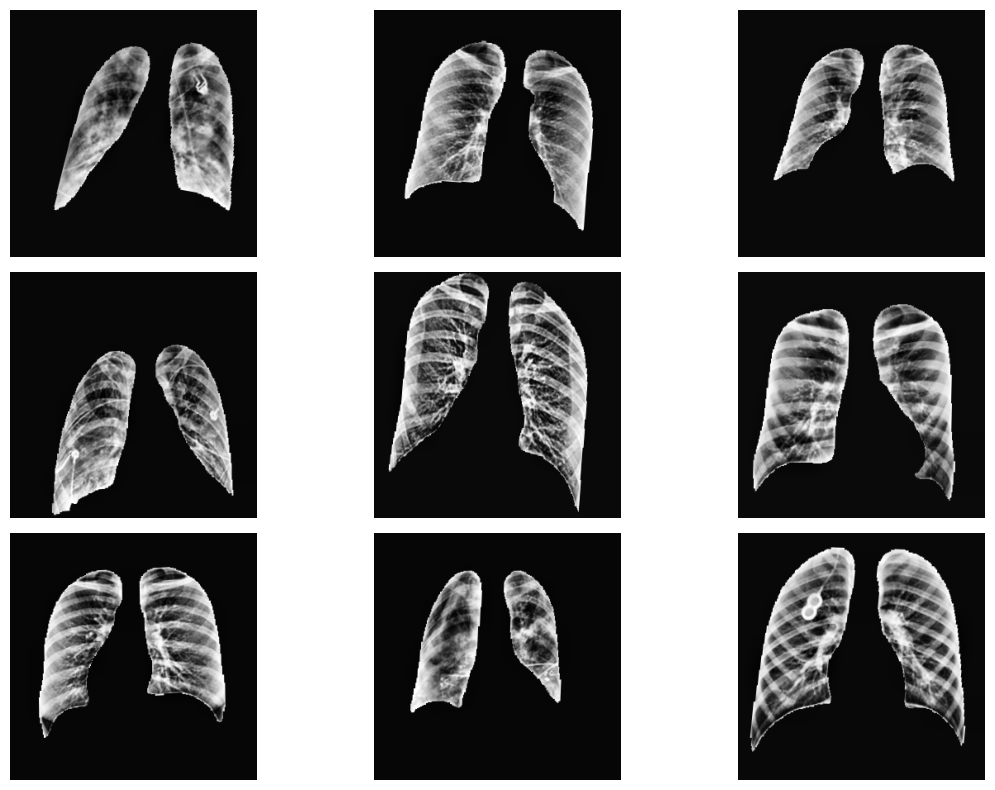

In [38]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Export des données Train non augmentées, Validation et Test

In [39]:
# Dossier de sortie du dataset découpé (3 classes)

split_output_path = Path(
    "../../../COVID-19_Radiography_Dataset_split_3classes"
)

split_output_path.mkdir(
    parents=True,
    exist_ok=True
)


def exporter_split(
    df_split,
    split_name,
    output_path
):

    for _, row in df_split.iterrows():

        src_path = Path(row["filepath"])
        classe = row["class"]

        dest_dir = (
            output_path
            / split_name
            / classe
        )

        dest_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        dest_path = (
            dest_dir
            / src_path.name
        )

        shutil.copy2(
            src_path,
            dest_path
        )

    print(
        f"{split_name:<10} : "
        f"{len(df_split)} images exportées."
    )


# Export des trois jeux
exporter_split(
    train_df,
    "train",
    split_output_path
)

exporter_split(
    val_df,
    "validation",
    split_output_path
)

exporter_split(
    test_df,
    "test",
    split_output_path
)

print("\nDataset exporté dans :")
print(split_output_path.resolve())

train      : 16668 images exportées.
validation : 2083 images exportées.
test       : 2084 images exportées.

Dataset exporté dans :
C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_split_3classes


## 8. Export des données Train augmentées

In [40]:
# Dossier de sortie des données augmentées
train_augmented_path = (
    split_output_path
    / "train_augmented"
)

# Nombre d'images augmentées générées
# par image originale
N_AUG = 1

# Création des dossiers des trois classes
for classe in classes:

    (
        train_augmented_path
        / classe
    ).mkdir(
        parents=True,
        exist_ok=True
    )

# Copie des images originales
for _, row in train_df.iterrows():

    src = Path(row["filepath"])

    dst = (
        train_augmented_path
        / row["class"]
        / src.name
    )

    shutil.copy2(
        src,
        dst
    )

print(
    "Images originales copiées dans "
    "train_augmented."
)

print(
    "Nombre d'images copiées :",
    len(train_df)
)

Images originales copiées dans train_augmented.
Nombre d'images copiées : 16668


In [41]:
# Générateur dédié à l'export des images augmentées

export_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="class",
    classes=classes,
    target_size=IMAGE_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    batch_size=1,
    shuffle=False
)

print("\nClasses détectées :")
print(export_generator.class_indices)

Found 16668 validated image filenames belonging to 3 classes.

Classes détectées :
{'COVID': 0, 'Normal': 1, 'Pneumonia': 2}


In [42]:
# Génération et sauvegarde des images augmentées

for aug_idx in range(1, N_AUG + 1):
    
    export_generator.reset()
    
    for i in range(len(train_df)):
        
        image, label = next(export_generator)
        
        img = image[0].squeeze()
        
        # Conversion en uint8 si nécessaire
        if img.max() <= 1.0:
            img = (img * 255).astype(np.uint8)
        else:
            img = img.astype(np.uint8)
        
        classe = train_df.iloc[i]["class"]
        original_path = Path(train_df.iloc[i]["filepath"])
        original_stem = original_path.stem
        
        output_file = train_augmented_path / classe / f"{original_stem}_aug{aug_idx}.png"
        
        cv2.imwrite(str(output_file), img)

print("Images augmentées enregistrées dans :", train_augmented_path.resolve())

Images augmentées enregistrées dans : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\COVID-19_Radiography_Dataset_split_3classes\train_augmented


## 9. Vérification des exports

In [43]:
def compter_split(split_output_path):

    lignes = []

    for split_name in ["train", "train_augmented", "validation", "test"]:

        split_dir = split_output_path / split_name

        for classe in classes:

            classe_dir = split_dir / classe

            nb_images = len(list(classe_dir.glob("*.png"))) if classe_dir.exists() else 0

            lignes.append({
                "split": split_name,
                "classe": classe,
                "nb_images": nb_images
            })

    return pd.DataFrame(lignes)


display(compter_split(split_output_path))

,split,classe,nb_images
0,train,COVID,2698
1,train,Normal,8109
2,train,Pneumonia,5861
3,train_augmented,COVID,5396
4,train_augmented,Normal,16218
5,train_augmented,Pneumonia,11722
6,validation,COVID,338
7,validation,Normal,1013
8,validation,Pneumonia,732
9,test,COVID,337
